# Họ và Tên: Nguyễn Phước Thành
# MSSV: 2374802013578

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:

* Viết chương trình sử dụng median filter để làm mịn ảnh. (0.5 điểm)  
* Viết chương trình sử dụng Sobel filter để xác định biên của hình ảnh. (0.5 điểm)  
* Đổi màu ảnh bằng cách hoán đổi thứ tự các kênh màu (ví dụ: BGR → GRB hoặc GBR...) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
* Chuyển ảnh sang không gian màu LAB và tách riêng 3 kênh L, A, B, lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`). (0.5 điểm)


Viết chương trình sử dụng median filter để làm mịn

[[ 99  99 104 ...  87  89  90]
 [ 98  99 104 ...  85  87  87]
 [ 98  98 104 ...  81  82  82]
 ...
 [ 39  39  39 ...  60  62  63]
 [ 39  45  39 ...  61  63  65]
 [ 39  45  39 ...  61  65  66]]


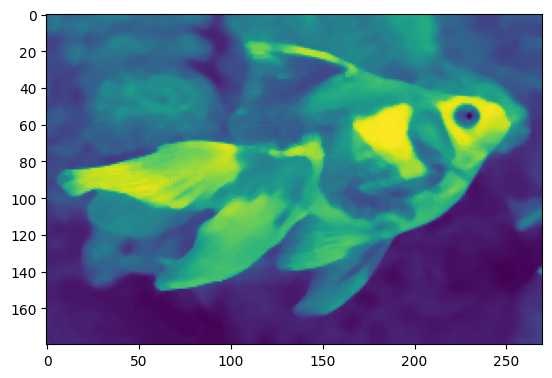

In [1]:
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as sn
import matplotlib.pyplot as plt
import colorsys

a = iio.imread("images/my_image.jpg", mode='F').astype(np.uint8)

b = sn.median_filter(a, size=5, footprint=None, output=None, mode='reflect', cval=0.0, origin=0)
iio.imsave('images/my_imgaes_median_filter.jpg', b)
print(b)
plt.imshow(b)
plt.show()

Viết chương trình sử dụng Sobel filter để xác định biên của hình ảnh

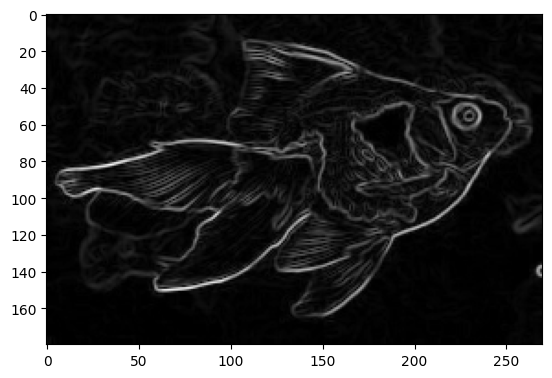

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as sn
from skimage import filters
import colorsys

a = iio.imread('images/my_image.jpg', mode = 'F')
b = filters.sobel(a).astype(np.uint8)
iio.imsave('images/my_image_sobel_filtered.jpg', b)
plt.imshow(b, cmap='gray')
plt.show()

Đổi màu ảnh bằng cách hoán đổi thứ tự các kênh màu (ví dụ: BGR → GRB hoặc GBR...) và lưu thành tên dạng `[ten_anh]_swapped.jpg

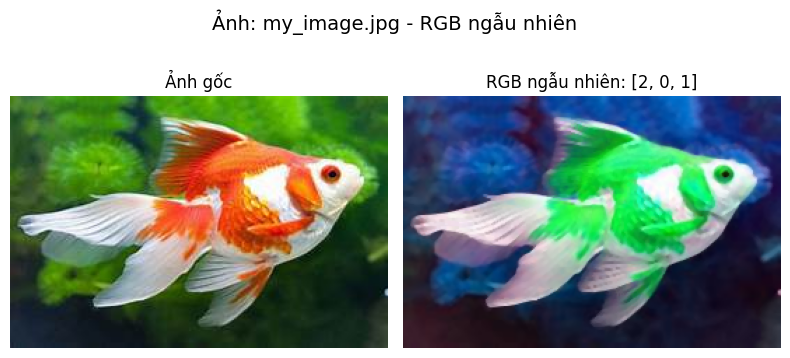

In [3]:
import numpy as np
import imageio.v2 as iio
import os
import random

input_folder = 'images'
output_folder = 'images'
filenames = ['my_image.jpg']

os.makedirs(output_folder, exist_ok=True)
def median_filter(image, k=3):
    pad = k // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='reflect')
    filtered = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k, j:j+k]
            filtered[i, j] = np.median(region)
    return filtered.astype(np.uint8)

for fname in filenames:
    path = os.path.join(input_folder, fname)
    img = iio.imread(path)

    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)

    denoised = np.zeros_like(img)
    for c in range(3):
        denoised[:, :, c] = median_filter(img[:, :, c], 3)

    channels = [0, 1, 2]
    random.shuffle(channels)
    img_random = denoised[:, :, channels]

    plt.figure(figsize=(8, 4))
    plt.suptitle(f'Ảnh: {fname} - RGB ngẫu nhiên', fontsize=14)

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Ảnh gốc')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_random)
    plt.title(f'RGB ngẫu nhiên: {channels}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    base = os.path.splitext(fname)[0]
    out_path = os.path.join(output_folder, f'my_image_swapped.jpg')
    iio.imwrite(out_path, img_random)


Chuyển ảnh sang không gian màu LAB và tách riêng 3 kênh L, A, B, lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`)

Đã lưu:
my_image_L.jpg
my_image_A.jpg
my_image_B.jpg


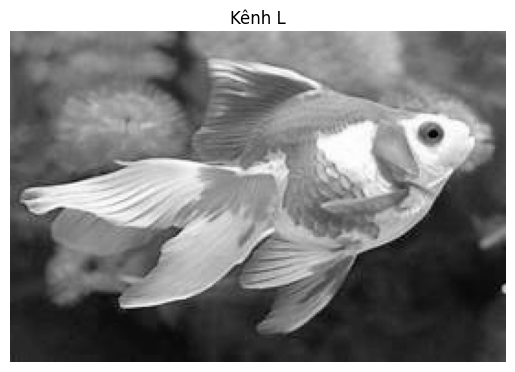

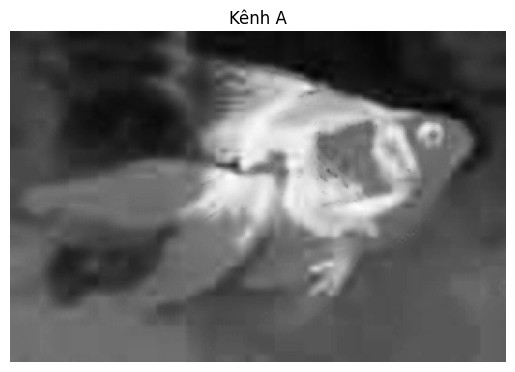

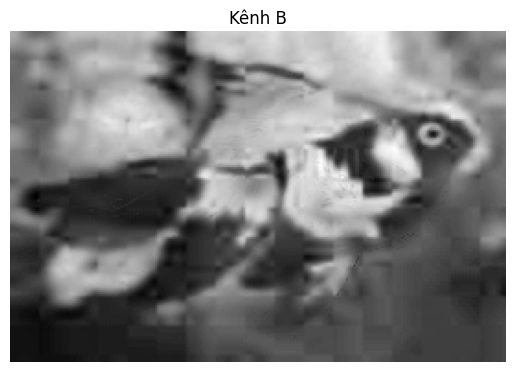

In [1]:
import imageio.v2 as iio
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab
import os

def show_gray(title, img):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
img_path = 'images/my_image.jpg'
img = iio.imread(img_path)

if img is None:
    print("Không thể đọc ảnh.")
    exit()
img_lab = rgb2lab(img)
L = img_lab[:, :, 0]
A = img_lab[:, :, 1]
B = img_lab[:, :, 2]

def normalize_to_uint8(channel):
    min_val = channel.min()
    max_val = channel.max()
    norm = (channel - min_val) / (max_val - min_val) * 255
    return norm.astype(np.uint8)

L_8bit = normalize_to_uint8(L)
A_8bit = normalize_to_uint8(A)
B_8bit = normalize_to_uint8(B)

filename = os.path.basename(img_path)
name_only = os.path.splitext(filename)[0]

iio.imwrite(f"images/{name_only}_L.jpg", L_8bit)
iio.imwrite(f"images/{name_only}_A.jpg", A_8bit)
iio.imwrite(f"images/{name_only}_B.jpg", B_8bit)

print("Đã lưu:")
print(f"{name_only}_L.jpg")
print(f"{name_only}_A.jpg")
print(f"{name_only}_B.jpg")

show_gray("Kênh L", L_8bit)
show_gray("Kênh A", A_8bit)
show_gray("Kênh B", B_8bit)


### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật lọc và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Gaussian Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Median Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Bilateral Filter (tham số ngẫu nhiên) (0.5 điểm)  
* Canny Edge Detection (thresholds ngẫu nhiên 50–150) (0.5 điểm)  
* Erosion (kernel 2x2 đến 5x5 ngẫu nhiên) (0.5 điểm)  
* Dilation (tương tự Erosion) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* B: Gaussian Blur  
* M: Median Blur  
* F: Bilateral Filter  
* E: Canny Edge  
* R: Erosion  
* D: Dilation (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_blur_dog.jpg`, `result_canny_image2.jpg` (0.5 điểm)


=== Chương trình xử lý ảnh nâng cao ===
Nhập đường dẫn 3 ảnh (VD: cat.jpg hoặc ./images/cat.jpg):

Nhấn phím để chọn kỹ thuật xử lý:
B - Gaussian Blur
M - Median Blur
F - Bilateral Filter
E - Canny Edge Detection
R - Erosion
D - Dilation

Chờ bạn nhấn phím (hoặc Q để thoát)...
Đã lưu: images/result_Median Blur_bird.jpg


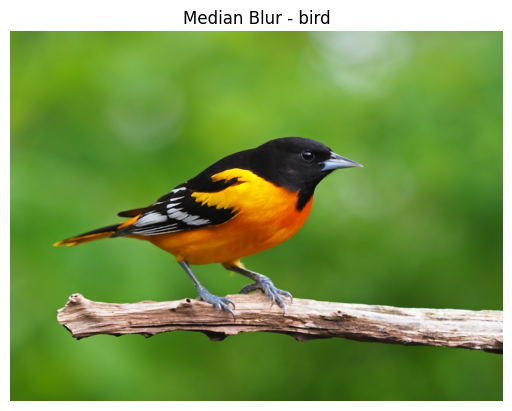

Đã lưu: images/result_Median Blur_my_image.jpg


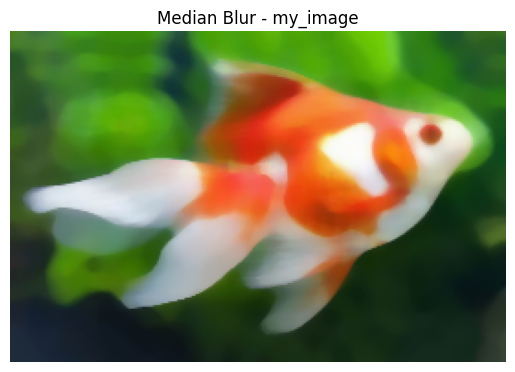

Đã lưu: images/result_Median Blur_pagoda.jpg


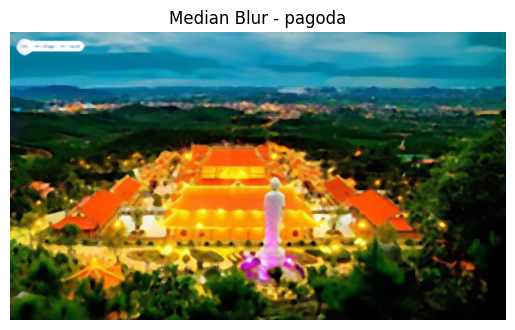


Chờ bạn nhấn phím (hoặc Q để thoát)...
Kết thúc chương trình.


In [6]:
import cv2
import random
import os
import matplotlib.pyplot as plt

def random_odd_kernel():
    return random.choice([3, 5, 7, 9, 11])

def random_square_kernel():
    size = random.randint(2, 5)
    return cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))

def show_image(title, img):
    if len(img.shape) == 2: 
        plt.imshow(img, cmap='gray')
    else:  
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

def process_images(images, method_key):
    for path in images:
        img = cv2.imread(path)
        if img is None:
            print(f"Không thể đọc ảnh: {path}")
            continue

        img_name = os.path.basename(path)
        name_without_ext = os.path.splitext(img_name)[0]
        result = img.copy()

        if method_key == 'B':
            ksize = random_odd_kernel()
            result = cv2.GaussianBlur(result, (ksize, ksize), 0)
            method_name = 'Gaussian Blur'
        elif method_key == 'M':
            ksize = random_odd_kernel()
            result = cv2.medianBlur(result, ksize)
            method_name = 'Median Blur'
        elif method_key == 'F':
            d = random.randint(5, 15)
            sigma_color = random.randint(50, 150)
            sigma_space = random.randint(50, 150)
            result = cv2.bilateralFilter(result, d, sigma_color, sigma_space)
            method_name = 'Bilateral Filter'
        elif method_key == 'E':
            t1 = random.randint(50, 100)
            t2 = random.randint(101, 150)
            result = cv2.Canny(result, t1, t2)
            method_name = 'Canny Edge'
        elif method_key == 'R':
            kernel = random_square_kernel()
            result = cv2.erode(result, kernel, iterations=1)
            method_name = 'Erosion'
        elif method_key == 'D':
            kernel = random_square_kernel()
            result = cv2.dilate(result, kernel, iterations=1)
            method_name = 'Dilation'
        else:
            print("Phím không hợp lệ.")
            return

        out_name = f"images/result_{method_name}_{name_without_ext}.jpg"
        cv2.imwrite(out_name, result)
        print(f"Đã lưu: {out_name}")

        show_image(f"{method_name} - {name_without_ext}", result)

print("=== Chương trình xử lý ảnh nâng cao ===")
print("Nhập đường dẫn 3 ảnh (VD: cat.jpg hoặc ./images/cat.jpg):")
images = [input(f"Ảnh {i+1}: ").strip() for i in range(3)]

print("\nNhấn phím để chọn kỹ thuật xử lý:")
print("B - Gaussian Blur")
print("M - Median Blur")
print("F - Bilateral Filter")
print("E - Canny Edge Detection")
print("R - Erosion")
print("D - Dilation")

while True:
    print("\nChờ bạn nhấn phím (hoặc Q để thoát)...")
    key = input(">> ").upper()
    if key == 'Q':
        print("Kết thúc chương trình.")
        break
    elif key in ['B', 'M', 'F', 'E', 'R', 'D']:
        process_images(images, key)
    else:
        print("Phím không hợp lệ. Vui lòng chọn lại.")


### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Tăng kích thước ảnh đầu tiên thêm 35 pixel ở mỗi cạnh. (0.5 điểm)  
* Xoay ảnh thứ hai 135 độ và lật ngang. (0.5 điểm)  
* Tăng kích thước ảnh thứ ba lên 5 lần và làm mịn bằng Gaussian blur kernel 9x9. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba bằng công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.5, 2.0], \quad \beta \in [-50, 50]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


=== Xử lý 3 ảnh theo yêu cầu ===


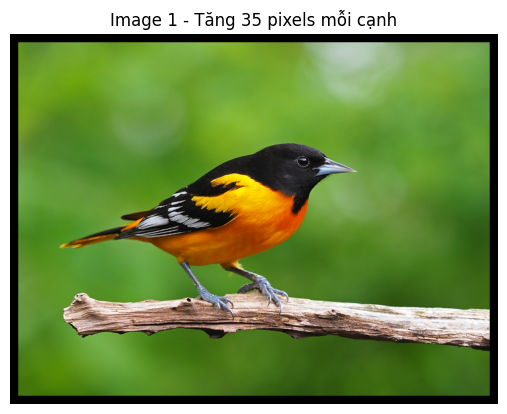

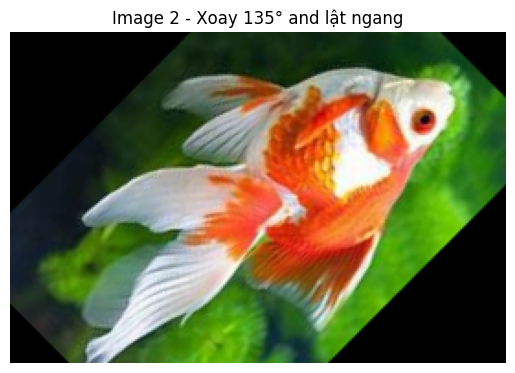

Alpha (tương phản): 1.52, Beta (độ sáng): 7


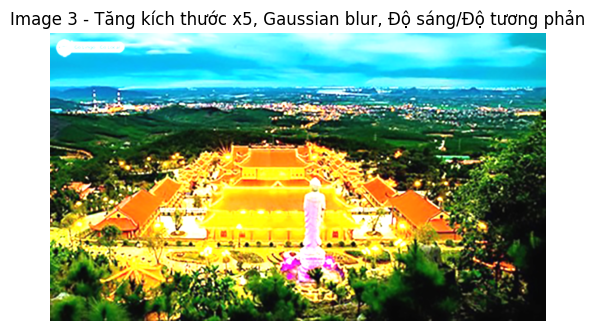

In [9]:
import cv2
import numpy as np
import random
import os
import matplotlib.pyplot as plt

def show_image(title, img):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

print("=== Xử lý 3 ảnh theo yêu cầu ===")
images = [input(f"Nhập đường dẫn ảnh {i+1}: ").strip() for i in range(3)]

img1 = cv2.imread(images[0])
img2 = cv2.imread(images[1])
img3 = cv2.imread(images[2])

if img1 is None or img2 is None or img3 is None:
    print("Một trong các ảnh không thể đọc được. Kiểm tra lại đường dẫn.")
    exit()

img1_border = cv2.copyMakeBorder(
    img1, 35, 35, 35, 35, borderType=cv2.BORDER_CONSTANT, value=(0, 0, 0)
)
cv2.imwrite("images/result_image1_padded.jpg", img1_border)
show_image("Image 1 - Tăng 35 pixels mỗi cạnh", img1_border)

(h, w) = img2.shape[:2]
center = (w // 2, h // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, 135, 1.0)
rotated = cv2.warpAffine(img2, rotation_matrix, (w, h))
flipped = cv2.flip(rotated, 1) 
cv2.imwrite("images/result_image2_rotated_flipped.jpg", flipped)
show_image("Image 2 - Xoay 135° and lật ngang", flipped)

img3_scaled = cv2.resize(img3, None, fx=5.0, fy=5.0, interpolation=cv2.INTER_LINEAR)

img3_blurred = cv2.GaussianBlur(img3_scaled, (9, 9), 0)

alpha = random.uniform(0.5, 2.0)
beta = random.randint(-50, 50)
img3_adjusted = cv2.convertScaleAbs(img3_blurred, alpha=alpha, beta=beta)

cv2.imwrite("images/result_image3_scaled_blurred_adjusted.jpg", img3_adjusted)
print(f"Alpha (tương phản): {alpha:.2f}, Beta (độ sáng): {beta}")
show_image("Image 3 - Tăng kích thước x5, Gaussian blur, Độ sáng/Độ tương phản", img3_adjusted)


# Chúc các bạn làm bài may mắn, hi vọng mọi người qua môn tất cả được 10.